# Processing Workflows

While the descriptions from the first notebook are nice, they're not research data or archival metadata.

This next section details a workflow that will process your materials into a structured format that can be used for research or library systems. This is an example that can be adapted to your specific needs.

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1-wksvuqBUv8qq2mLJ8EbbluStjyvXIp7#scrollTo=OsonjvCPSjIr)  

# Select Model

There are many open-source models for OCR or HTR available. The Qwen family (q-when) of models has led the way as a tool to extract handwritten text. There are many models adapted from [Qwen](https://huggingface.co/Qwen), such as the [Nanonets OCR model](https://huggingface.co/nanonets/Nanonets-OCR-s), which preserves structured information like tables or forms.

For this workshop, you can test either "Qwen/Qwen3-VL-30B-A3B-Instruct" or "nanonets/Nanonets-OCR-s"

In [3]:
model_id = "Qwen/Qwen3-VL-30B-A3B-Instruct" 

# Workflow Requirements
- Input is the URL for a box manifest in EAP (other other IIIF collection)
- We need to predict individual items in the folder or box.
- We need to recognize the relevant entites (people, places, organizations) in each item in the context of the larger collection. For a legal case, for example, we only need entitle in the case as well as their relationship to the case (e.g. plaintiff, judge, victim).

# Strategy

- Extract the text of all individual images
- Use text and descriptions to predict individual items (a two-page letter, a 50-page memo...)
- Generate item-level research metadata

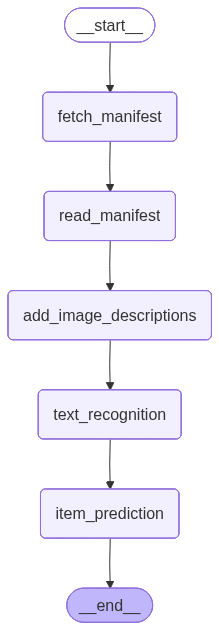

In [7]:
from IPython.display import Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
# https://langchain-ai.github.io/langgraph/tutorials/workflows/#prompt-chaining

from typing_extensions import TypedDict

class Box(TypedDict): #Level: File in EAP
    box_manifest_uri: str
    box_manifest_data: dict
    box_metadata: dict
    box_summary: str
    people: list[str]
    places: list[str]
    organizations: list[str]
    image_urls: list[str]
    images: list[dict]
    items: dict
    sample: int # Process only first n images in the box

In [12]:
from tqdm import tqdm 

# Nodes
def fetch_manifest(state: Box) -> Box:
  import requests
  header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/11"
  }
  manifest = requests.get(state['box_manifest_uri'], headers=header)
  if manifest.status_code != 200:
    raise Exception(f"Error downloading manifest: {manifest.status_code}")
  print("Fetched manifest successfully!")
  return { "box_manifest_data": manifest.json() }


def read_manifest(state: Box) -> Box:
    images = []
    for canvas in  state["box_manifest_data"]["sequences"][0]["canvases"]:
      for image in canvas["images"]:
        image_uri = image.get('resource', None).get('@id', None)
        if image_uri:
          images.append(image_uri)
    metadata = {}
    for item in state["box_manifest_data"]["metadata"]:
       metadata[item["label"]] = item["value"]
    print(f"Found {len(images)} images in manifest!!")
    return { "box_manifest_uri": state["box_manifest_uri"], "box_manifest_data": state["box_manifest_data"], "image_urls": images, "box_metadata": metadata }

def add_image_descriptions(state: Box) -> Box: 
  custom_llm = GradioChatModel()
  images = [{"image_url": url} for url in state["image_urls"]]
  for image in tqdm(images, desc="Adding descriptions to images"):
    prompt = """Describe the contents of the image.\nUse the following metadata as context: \n"""
    for key, value in state["box_metadata"].items():
      prompt += f"- {key}: {value}\n"
    msg = HumanMessageWithImage(content=prompt, image=image["image_url"])
    result = custom_llm.invoke([msg])
    image["description"] = result.content
  state["images"] = images
  return state

def text_recognition(state:Box) -> Box:
    """Extract any text present in the document. Preserve formatting as markdown."""
    custom_llm = GradioChatModel()
    images = state["images"]
    for image in tqdm(images, desc="Extracting text from images"):
      prompt = "If printed or handwritten text is present in the image, extract typewritten and handwritten text from the page. Otherwise return nothing. Retain formatting as markdown."
      msg = HumanMessageWithImage(content=prompt, image=image['image_url'])
      result = custom_llm.invoke([msg])
      image['markdown_text'] = result.content
    state["images"] = images
    return state

def item_prediction(state: Box) -> Box:
  # Placeholder for future processing steps
  from langchain_core.messages import HumanMessage
  custom_llm = GradioChatModel()
  images = state["images"]
  prompt = """Your are an archival processing assistant. You have descriptions and text from individual pages in a box. Each image is identified by an <image> tag. Group the images into groups that identify coherent items. For example, the images may be the front and back of the same page. Two pages may be the start and end of a letter. You may have images that start or end a folder. Return only a list of grouped images as JSON and your reaonsing. For example: {"items":[[1,2],[3],[4,5,6]], "reasoning:"..."}"""
  prompt += "\nUse the following metadata for context, particularly look for types of documents and document groupings (i.e. letters, folders, photographs):\n"
  for key, value in state["box_metadata"].items():
      prompt += f"- {key}: {value}\n"
  prompt += "\n\nHere are the image descriptions and text:\n\n"
  for i, image in enumerate(images):
    prompt += f"<image {i}>description: {image['description']}; text {image['markdown_text']}</image {i}>"
  msg = HumanMessage(content=prompt)
  result = custom_llm.invoke([msg])
  # convert result content to dict
  if result:
    import json
    state["items"] = json.loads(result.content)
  return state


In [13]:
from langgraph.graph import StateGraph, START, END

# Build workflow
builder = StateGraph(Box)
# Add nodes
builder.add_node("fetch_manifest", fetch_manifest)
builder.add_node("read_manifest", read_manifest)
builder.add_node("add_image_descriptions", add_image_descriptions)
builder.add_node("text_recognition", text_recognition)
builder.add_node("item_prediction", item_prediction)

# Add edges to connect nodes
builder.add_edge(START, "fetch_manifest")
builder.add_edge("fetch_manifest", "read_manifest")
builder.add_edge("read_manifest", "add_image_descriptions")
builder.add_edge("add_image_descriptions", "text_recognition")
builder.add_edge("text_recognition", "item_prediction")
builder.add_edge("item_prediction", END)
# Compile
graph = builder.compile()


In [14]:
# Invoke

output = graph.invoke({"box_manifest_uri": "https://eap.bl.uk/archive-file/EAP699-23-1/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP699-23-1/manifest"})
#TODO add start, end index for images in box 

from rich import print
print(output)

Fetched manifest successfully!
Found 4 images in manifest!!
Loaded as API: https://apjanco-fantastic-futures.hf.space ✔


Adding descriptions to images: 100%|██████████| 4/4 [03:00<00:00, 45.21s/it]


Loaded as API: https://apjanco-fantastic-futures.hf.space ✔


Extracting text from images: 100%|██████████| 4/4 [01:45<00:00, 26.35s/it]


Loaded as API: https://apjanco-fantastic-futures.hf.space ✔


{
    'box_manifest_uri': 
'https://eap.bl.uk/archive-file/EAP699-23-1/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP699-23-1/manifest
',
    'box_manifest_data': {
        '@context': 'http://iiif.io/api/presentation/2/context.json',
        '@id': 'https://eap.bl.uk/archive-file/EAP699-23-1',
        '@type': 'sc:Manifest',
        'label': 'Photographs',
        'description': '',
        'logo': 'https://eap.bl.uk/themes/custom/eap/images/bl_logo_100.gif',
        'attribution': 'Except as otherwise permitted under your national copyright law this material may not be 
copied or distributed further',
        'license': '',
        'viewingHint': 'individuals',
        'viewingDirection': 'left-to-right',
        'metadata': [
            {'label': 'Identifier', 'value': 'EAP699/23/1'},
            {'label': 'Title', 'value': 'Photographs'},
            {'label': 'Place', 'value': 'Moldova, Europe'},
            {
                'label': 'Link to catalogue record',
                'value': '<a href="https://eap.bl.uk/archive-file/EAP699-23-1">View the catalogue record</a>'
            },
            {
                'label': 'Citation',
                'value': 'Photographs, British Library, EAP699/23/1, https://eap.bl.uk/archive-file/EAP699-23-1'
            },
            {
                'label': 'Digitised by',
                'value': 'Institute of the Cultural Heritage of the Academy of Sciences of Moldova'
            },
            {'label': 'Digitisation funded by', 'value': 'Endangered Archives Programme supported by Arcadia'},
            {'label': 'Language', 'value': 'Romanian, Russian'},
            {'label': 'Scripts', 'value': 'Cyrillic, Latin'}
        ],
        'sequences': [
            {
                '@id': 'https://eap.bl.uk/archive-file/EAP699-23-1/sequence',
                '@type': 'sc:Sequence',
                'label': 'Current Page Order',
                'viewingHint': 'individuals',
                'startCanvas': 'https://eap.bl.uk/archive-file/EAP699-23-1/canvas/1',
                'canvases': [
                    {
                        '@id': 'https://eap.bl.uk/archive-file/EAP699-23-1/canvas/1',
                        '@type': 'sc:Canvas',
                        'label': '1',
                        'width': 4633,
                        'height': 3286,
                        'images': [
                            {
                                '@type': 'oa:Annotation',
                                'motivation': 'sc:painting',
                                'resource': {
                                    '@id': 
'https://images.eap.bl.uk/EAP699/EAP699_23_1/1.jp2/full/full/0/default.jpg',
                                    '@type': 'dctypes:Image',
                                    'format': 'image/jpg',
                                    'service': {
                                        '@context': 'http://iiif.io/api/image/2/context.json',
                                        '@id': 'https://images.eap.bl.uk/EAP699/EAP699_23_1/1.jp2',
                                        'protocol': 'http://iiif.io/api/image',
                                        'width': 1534,
                                        'height': 2468,
                                        'tiles': [{'scaleFactors': [1, 2, 4, 8, 16, 32], 'width': 256}],
                                        'profile': [
                                            'http://iiif.io/api/image/2/level2.json',
                                            {
                                                'qualities': ['gray', 'color', 'bitonal'],
                                                'supports': [
                                                    'profileLinkHeader',
                                                    'rotationArbitrary',
                                                    'regionSquare',
                                                    'mirroring'
                      